# EV Battery Failure Prediction: Exploratory Data Analysis

This notebook explores the **EV Battery Failure Prediction Dataset**, a 200,000-row,
70-column synthetic telemetry dataset covering 20 EV brands and 5 battery chemistries
(LFP, NMC, NCA, LMO, LTO). The target, `battery_failure`, was built from real
battery-engineering relationships (cycle aging, thermal stress, charging habits,
driving behavior, maintenance quality) rather than random noise, so it's a good
playground for feature engineering, imbalanced classification, and battery-health
research more broadly.

## Before You Dive In

This notebook focuses on exploratory data analysis. If you'd like to explore the dataset in more detail, you can visit the **dataset page**, where you'll find:

- **EV Battery Failure Prediction Dataset** (`.csv`)
- **Data Dictionary** (`.csv`) with definitions for every feature
- **Feature Description** (`.md`) explaining the variables and their engineering rationale
- An overview of the synthetic data generation process and dataset assumptions

These resources provide additional context for the analysis and are useful if you plan to build your own machine learning models, engineer new features, or perform further research using the dataset.

**What this notebook covers:**
- Dataset overview, structure, and missing values
- Target distribution and class imbalance
- Battery chemistry and brand-level patterns
- Degradation relationships (cycle count, capacity loss, thermal risk)
- Charging and driving behavior vs. failure
- Environmental and maintenance effects
- Correlation analysis and key takeaways


# 1. Setup

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sarveshchhetri/ev-battery-failure-prediction-dataset-200k/data_dictionary.csv
/kaggle/input/datasets/sarveshchhetri/ev-battery-failure-prediction-dataset-200k/feature_descriptions.md
/kaggle/input/datasets/sarveshchhetri/ev-battery-failure-prediction-dataset-200k/ev_battery_failure_dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
df= pd.read_csv('/kaggle/input/datasets/sarveshchhetri/ev-battery-failure-prediction-dataset-200k/ev_battery_failure_dataset.csv')

In [4]:
print('Shape of the dataset:',df.shape)
df.head()

Shape of the dataset: (200000, 70)


,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,...,0.0,3.0,1.0,23.4,32.5,58.2,NaN,NaN,867.0,0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,...,3.0,2.0,1.0,51.2,45.4,51.0,NaN,100.0,1090.0,0


# 2. Dataset Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   vehicle_id                       200000 non-null  object 
 1   vehicle_brand                    193564 non-null  object 
 2   vehicle_model                    191796 non-null  object 
 3   vehicle_type                     193568 non-null  object 
 4   manufacturing_year               190171 non-null  float64
 5   battery_manufacturer             193812 non-null  object 
 6   battery_chemistry                192786 non-null  object 
 7   battery_capacity_kwh             193097 non-null  float64
 8   drive_type                       192732 non-null  object 
 9   odometer_km                      191334 non-null  float64
 10  vehicle_age_years                192317 non-null  float64
 11  fleet_or_private                 191050 non-null  object 
 12  ba

In [6]:
df.describe()

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
count,190171.000000,193097.000000,191334.000000,192317.000000,192348.000000,191018.000000,190364.000000,191687.000000,190435.000000,190602.000000,...,190326.000000,190948.000000,192400.000000,192691.000000,191635.000000,193671.000000,192814.000000,193190.000000,191026.000000,200000.000000
mean,2019.501333,76.236405,102822.193327,6.495245,296.383934,87.381787,54.847079,38.290397,87.297020,3.288515,...,1.331032,2.024745,0.494595,35.179580,29.912538,63.538378,50.989061,40.948318,1859.485986,0.099605
std,2.873497,21.302330,87965.819977,2.878180,282.614453,12.540742,21.450372,12.754524,12.527256,0.246766,...,1.265969,1.579874,0.729369,21.789144,28.011328,13.764340,27.815242,29.848473,1834.356925,0.299473
min,2015.000000,25.000000,500.000000,1.370000,1.000000,21.420000,2.000000,5.000000,21.800000,2.048500,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,60.980000,36128.000000,4.000000,95.000000,80.990000,40.070000,29.600000,80.910000,3.106025,...,0.000000,1.000000,0.000000,19.300000,6.900000,53.900000,30.600000,15.500000,891.000000,0.000000
50%,2020.000000,75.350000,78919.000000,6.340000,218.000000,91.120000,54.940000,38.280000,91.050000,3.355800,...,1.000000,2.000000,0.000000,33.200000,22.600000,61.400000,53.500000,38.900000,1245.000000,0.000000
75%,2022.000000,89.990000,146010.750000,9.000000,412.000000,97.430000,69.780000,46.910000,97.330000,3.463900,...,2.000000,3.000000,1.000000,48.500000,45.100000,74.000000,72.800000,63.000000,3085.000000,0.000000
max,2024.000000,149.010000,450000.000000,11.550000,3369.000000,99.800000,100.000000,92.030000,100.000000,3.853000,...,10.000000,13.000000,7.000000,100.000000,100.000000,100.000000,100.000000,100.000000,15474.000000,1.000000


In [7]:
# missing values in percentage
missing= ((df.isnull().sum())/df.shape[0]).sort_values(ascending=False)*100
missing.head(15)

fast_charge_ratio         4.9395
average_speed             4.9245
manufacturing_year        4.9145
home_charging_ratio       4.9025
sensor_fault_count        4.8370
charging_interruptions    4.8240
state_of_charge           4.8180
state_of_health           4.7825
capacity_loss_percent     4.7795
slow_charge_ratio         4.7415
cell_temperature_max      4.7250
cooling_system_health     4.7040
cell_voltage_avg          4.6990
charge_efficiency         4.6525
hard_braking_score        4.6195
dtype: float64

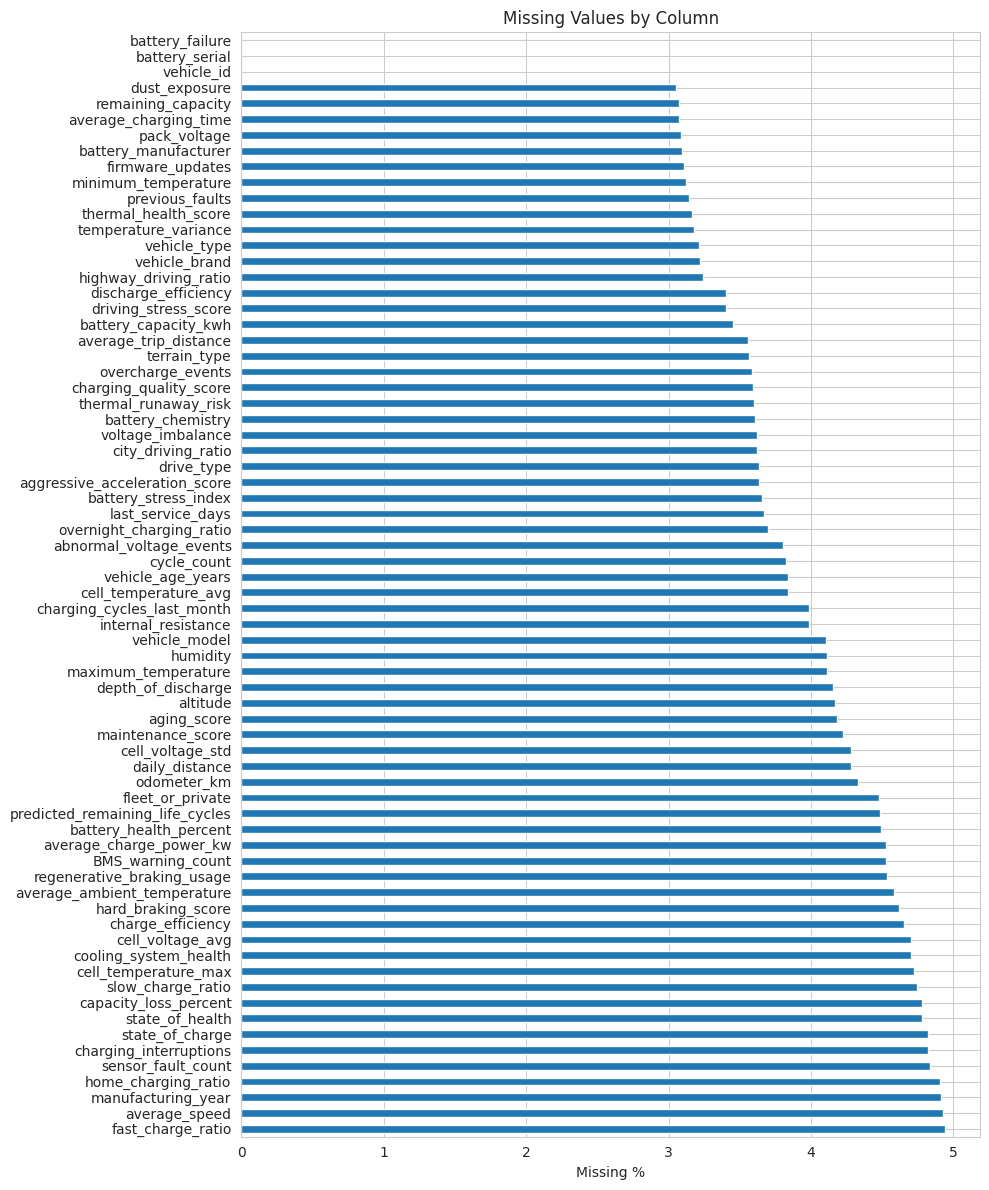

In [8]:
plt.figure(figsize=(10, 12))
missing.plot(kind="barh")
plt.xlabel("Missing %")
plt.title("Missing Values by Column")
plt.tight_layout()

# 3. Target Variable

In [9]:
fail_counts = df["battery_failure"].value_counts()
fail_pct = df["battery_failure"].value_counts(normalize=True) * 100

print(fail_counts)
print(fail_pct.round(2))

battery_failure
0    180079
1     19921
Name: count, dtype: int64
battery_failure
0    90.04
1     9.96
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Battery Failure Distribution')

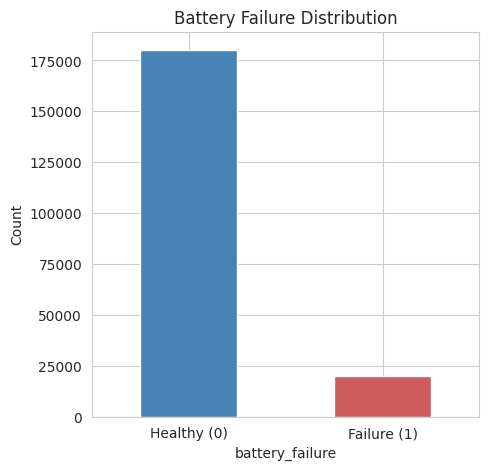

In [10]:
plt.figure(figsize=(5, 5))
df["battery_failure"].value_counts().plot(kind="bar", color=["steelblue", "indianred"])
plt.xticks([0, 1], ["Healthy (0)", "Failure (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Battery Failure Distribution")

# 4. Brand and Chemistry Breakdown

In [11]:
df["vehicle_brand"].value_counts()

vehicle_brand
Tesla         21840
BYD           20187
Volkswagen    14629
Hyundai       12940
GM            11087
Ford          10924
Kia           10780
Mercedes       9193
Nissan         9108
BMW            9063
Toyota         9039
Tata           7372
Audi           7287
Volvo          7276
Renault        7268
MG             5489
Mahindra       5464
Rivian         5452
Honda          5417
Lucid          3749
Name: count, dtype: int64

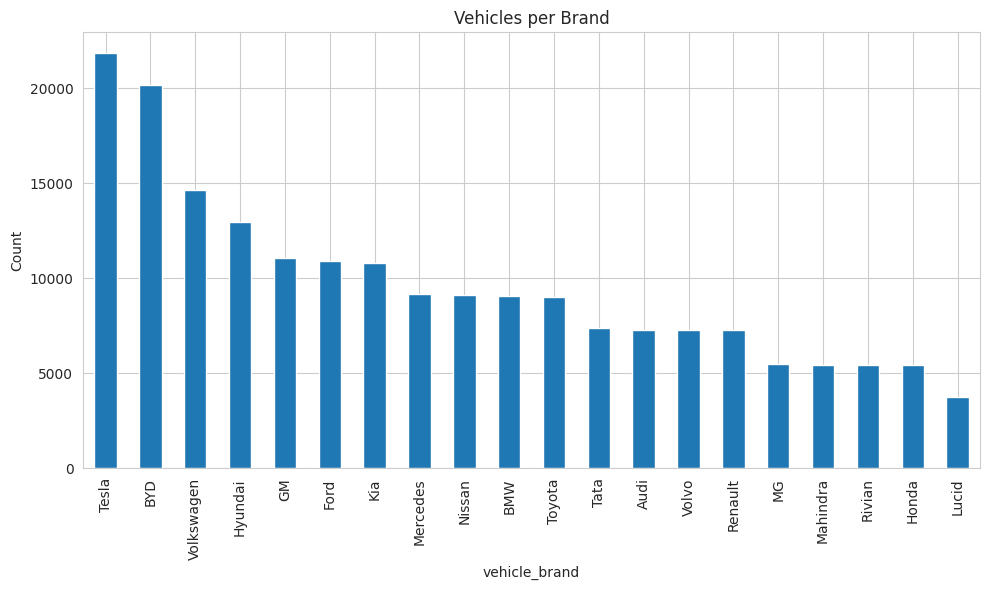

In [12]:
plt.figure(figsize=(10, 6))
df["vehicle_brand"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Vehicles per Brand")
plt.tight_layout()

In [13]:
df["battery_chemistry"].value_counts()

battery_chemistry
NMC    112993
LFP     53295
NCA     18424
LMO      5756
LTO      2318
Name: count, dtype: int64

Text(0.5, 1.0, 'Battery Chemistry Share')

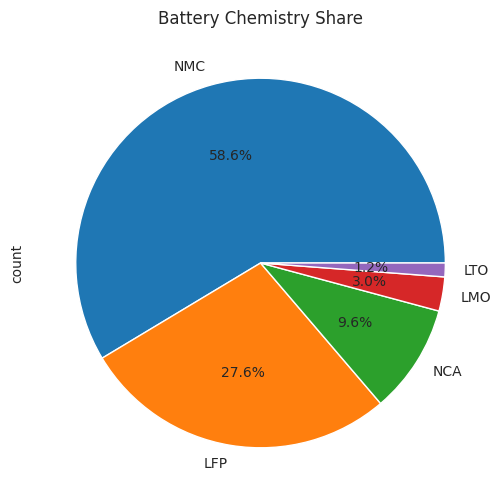

In [14]:
plt.figure(figsize=(6, 6))
df["battery_chemistry"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Battery Chemistry Share")

### failure rate by chemistry

In [15]:
chem_fail = df.groupby("battery_chemistry")["battery_failure"].mean().sort_values() * 100
chem_fail

battery_chemistry
LTO     0.000000
LFP     1.478563
NMC    12.123760
NCA    17.786583
LMO    24.339819
Name: battery_failure, dtype: float64

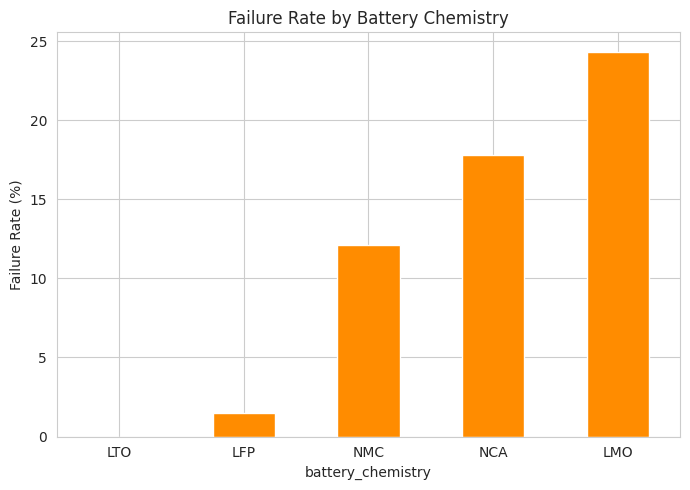

In [16]:
plt.figure(figsize=(7, 5))
chem_fail.plot(kind="bar", color="darkorange")
plt.ylabel("Failure Rate (%)")
plt.title("Failure Rate by Battery Chemistry")
plt.xticks(rotation=0)
plt.tight_layout()

### failure rate by fleet vs private ownership

In [17]:
fleet_fail = df.groupby("fleet_or_private")["battery_failure"].mean() * 100
fleet_fail

fleet_or_private
Fleet      26.291825
Private     3.600969
Name: battery_failure, dtype: float64

Text(0.5, 1.0, 'Failure Rate: Fleet vs Private')

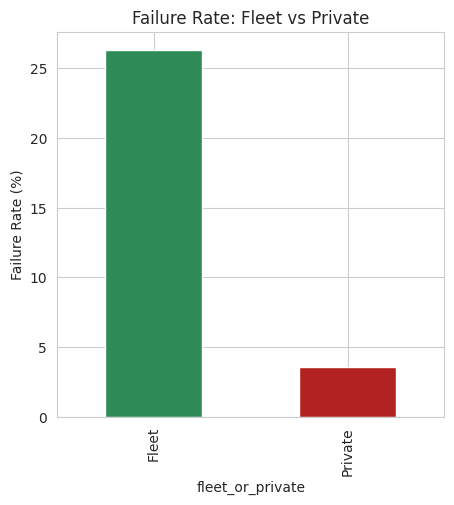

In [18]:
plt.figure(figsize=(5, 5))
fleet_fail.plot(kind="bar", color=["seagreen", "firebrick"])
plt.ylabel("Failure Rate (%)")
plt.title("Failure Rate: Fleet vs Private")

# 5. Battery degradation patterns

Text(0.5, 1.0, 'Battery Health vs Cycle Count, by Chemistry')

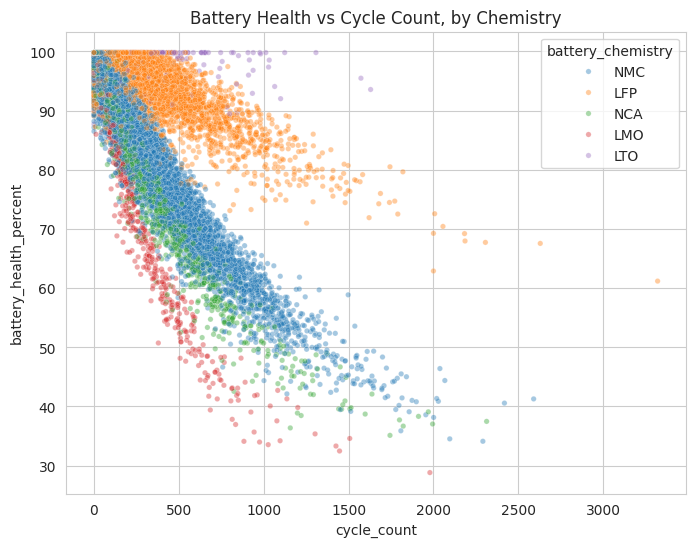

In [19]:
plt.figure(figsize=(8, 6))
sample = df.sample(20000, random_state=42)
sns.scatterplot( data=sample,x="cycle_count", y="battery_health_percent",hue="battery_chemistry",alpha=0.4, s=15)
plt.title("Battery Health vs Cycle Count, by Chemistry")

Text(0.5, 1.0, 'Capacity Loss Distribution by Failure Status')

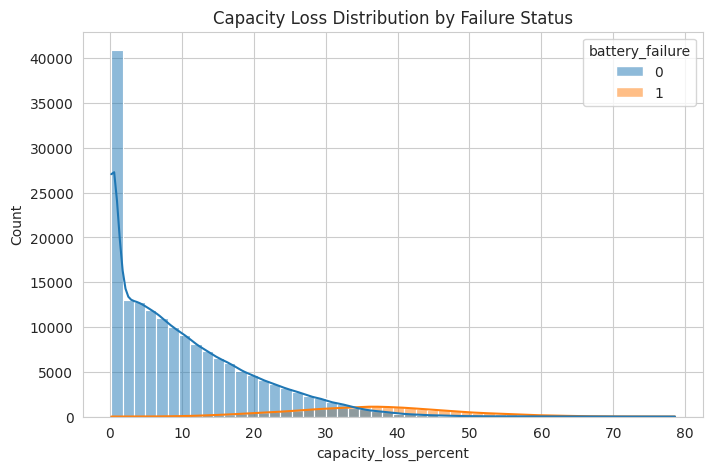

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="capacity_loss_percent", hue="battery_failure", bins=50, kde=True)
plt.title("Capacity Loss Distribution by Failure Status")

Text(0.5, 1.0, 'Battery Health Percent by Failure Status')

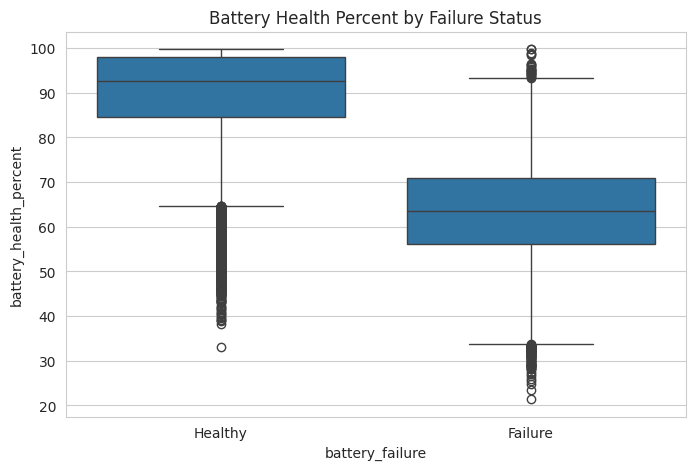

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="battery_health_percent")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("Battery Health Percent by Failure Status")

# 6. Changing behavior vs failure

Text(0.5, 1.0, 'Fast Charge Ratio by Failure Status')

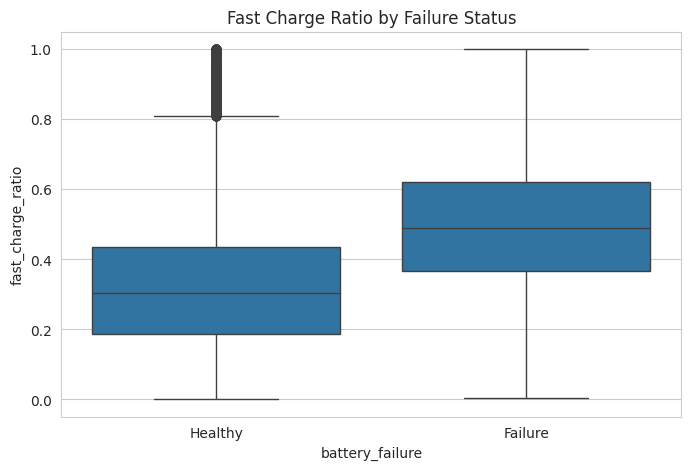

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="fast_charge_ratio")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("Fast Charge Ratio by Failure Status")

Text(0.5, 1.0, 'Charging Quality Score by Failure Status')

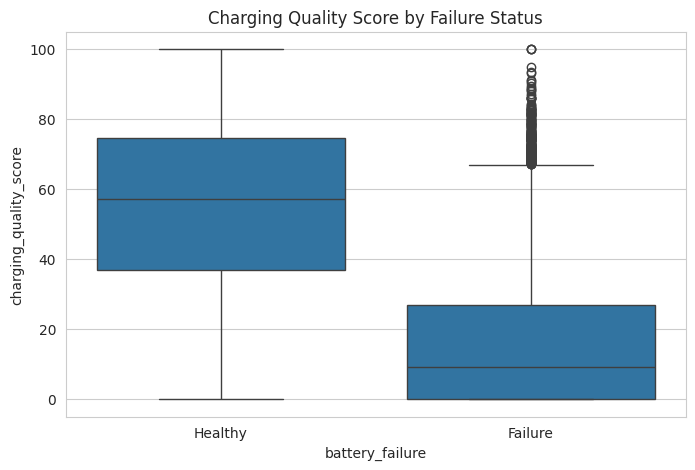

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="charging_quality_score")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("Charging Quality Score by Failure Status")

# 7. Driving behavior vs failure

Text(0.5, 1.0, 'Aggressive Acceleration Score by Failure Status')

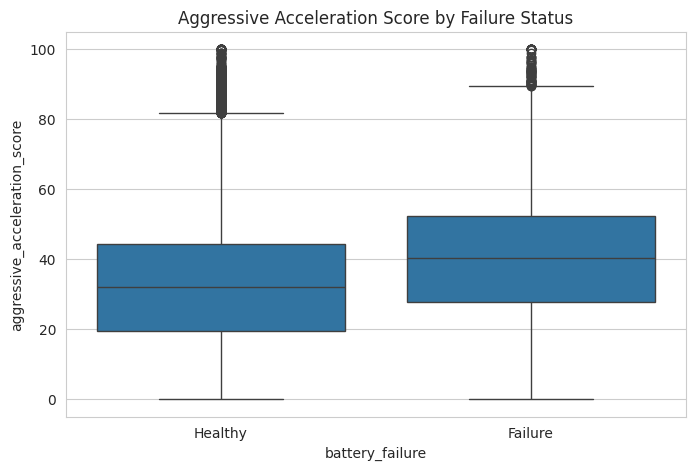

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="aggressive_acceleration_score")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("Aggressive Acceleration Score by Failure Status")

Text(0.5, 1.0, 'Driving Stress Score by Failure Status')

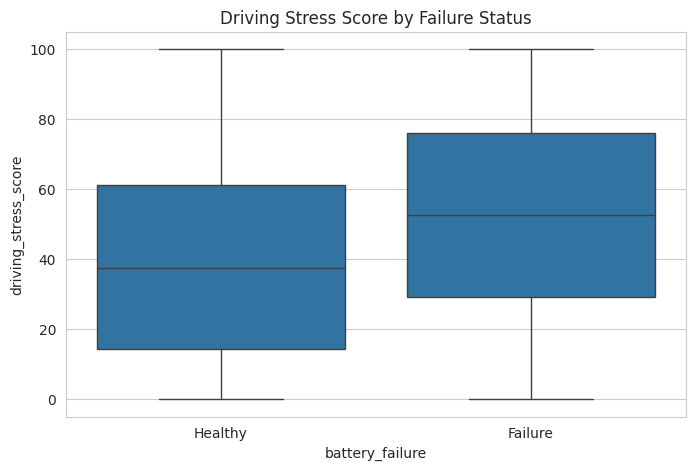

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="driving_stress_score")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("Driving Stress Score by Failure Status")

# 8. Environment and maintenance effects

Text(0.5, 1.0, 'Ambient Temperature by Failure Status')

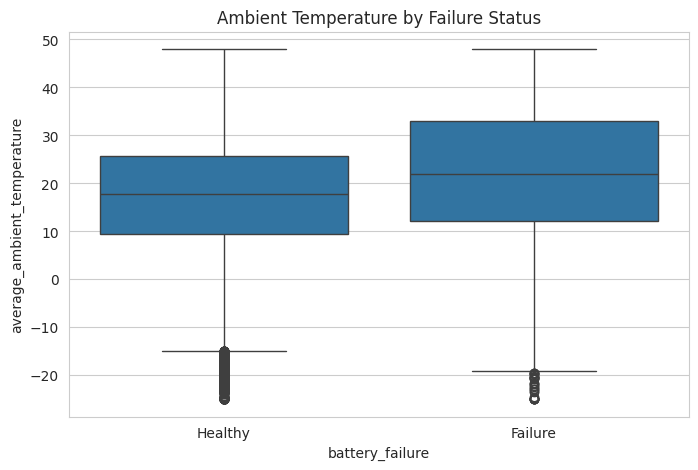

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="average_ambient_temperature")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("Ambient Temperature by Failure Status")

Text(0.5, 1.0, 'Maintenance Score by Failure Status')

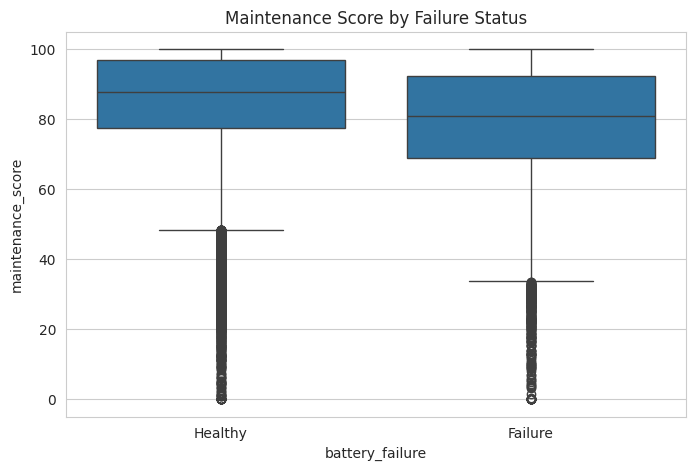

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="maintenance_score")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("Maintenance Score by Failure Status")

# 9. Diagnostic sensor signals

Text(0.5, 1.0, 'Thermal Runaway Risk by Failure Status')

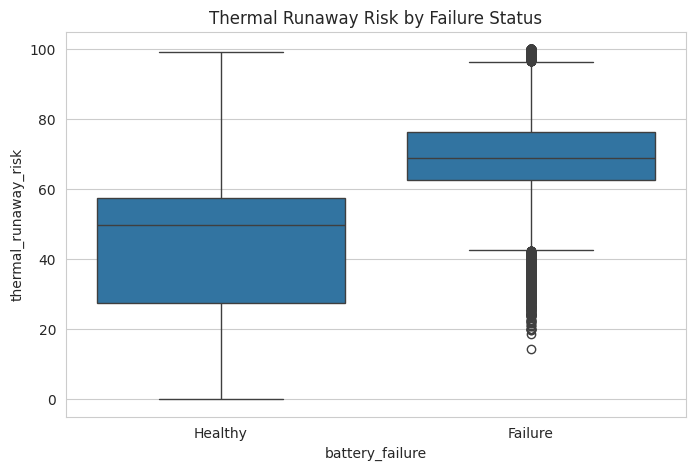

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="thermal_runaway_risk")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("Thermal Runaway Risk by Failure Status")

Text(0.5, 1.0, 'BMS Warning Count by Failure Status')

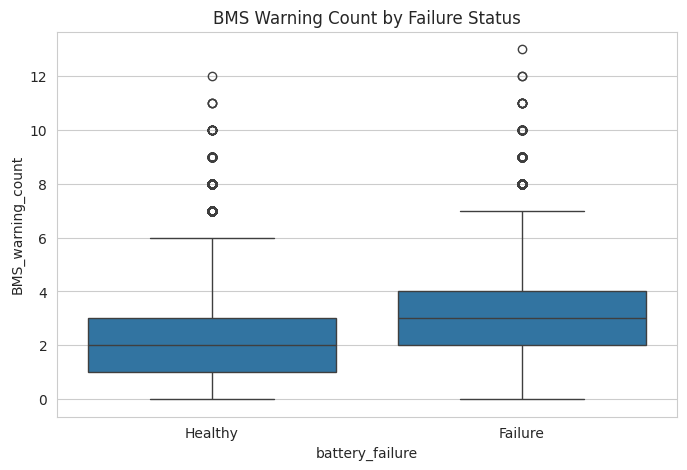

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="battery_failure", y="BMS_warning_count")
plt.xticks([0, 1], ["Healthy", "Failure"])
plt.title("BMS Warning Count by Failure Status")

# 10. Correlation with target

In [30]:
numeric_df = df.select_dtypes(include=np.number)
corr_with_target = numeric_df.corr()["battery_failure"].sort_values()
corr_with_target

battery_health_percent            -0.637646
state_of_health                   -0.635753
charge_efficiency                 -0.524607
charging_quality_score            -0.421923
thermal_health_score              -0.386968
remaining_capacity                -0.324448
cooling_system_health             -0.283633
slow_charge_ratio                 -0.280696
manufacturing_year                -0.268568
home_charging_ratio               -0.243346
predicted_remaining_life_cycles   -0.238656
discharge_efficiency              -0.207152
overnight_charging_ratio          -0.185739
average_charging_time             -0.177278
maintenance_score                 -0.135118
city_driving_ratio                -0.099432
battery_capacity_kwh              -0.098182
regenerative_braking_usage        -0.065518
humidity                          -0.051159
dust_exposure                     -0.002789
state_of_charge                   -0.001172
altitude                           0.001338
pack_voltage                    

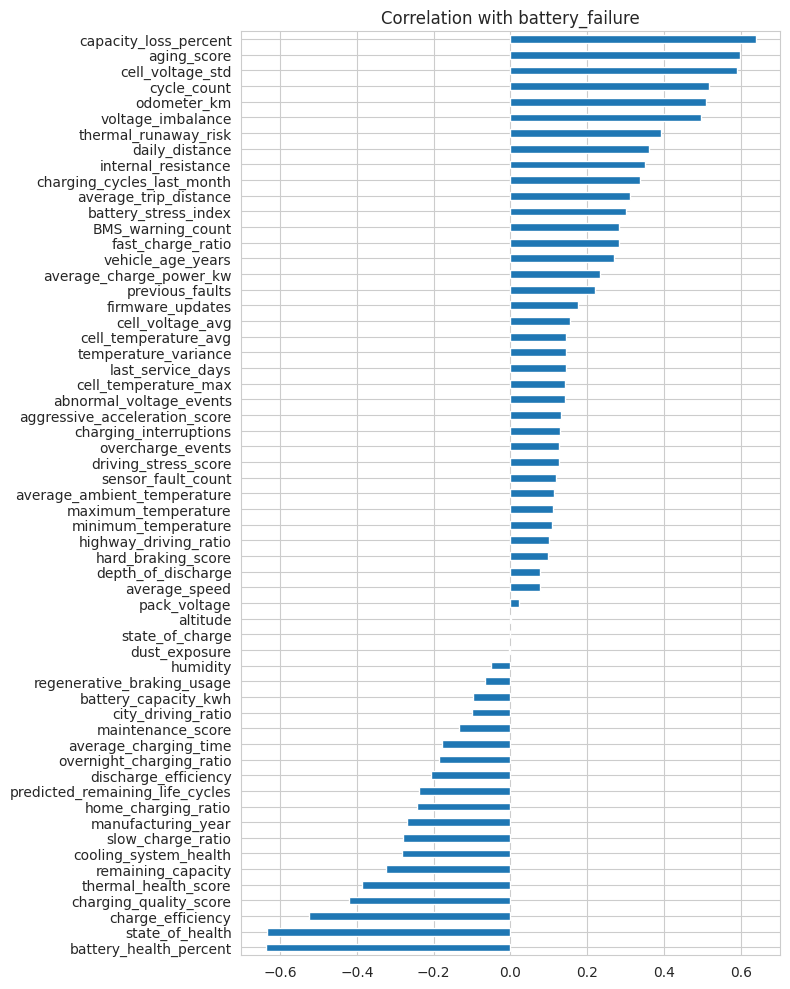

In [31]:
plt.figure(figsize=(8, 10))
corr_with_target.drop("battery_failure").plot(kind="barh")
plt.title("Correlation with battery_failure")
plt.tight_layout()

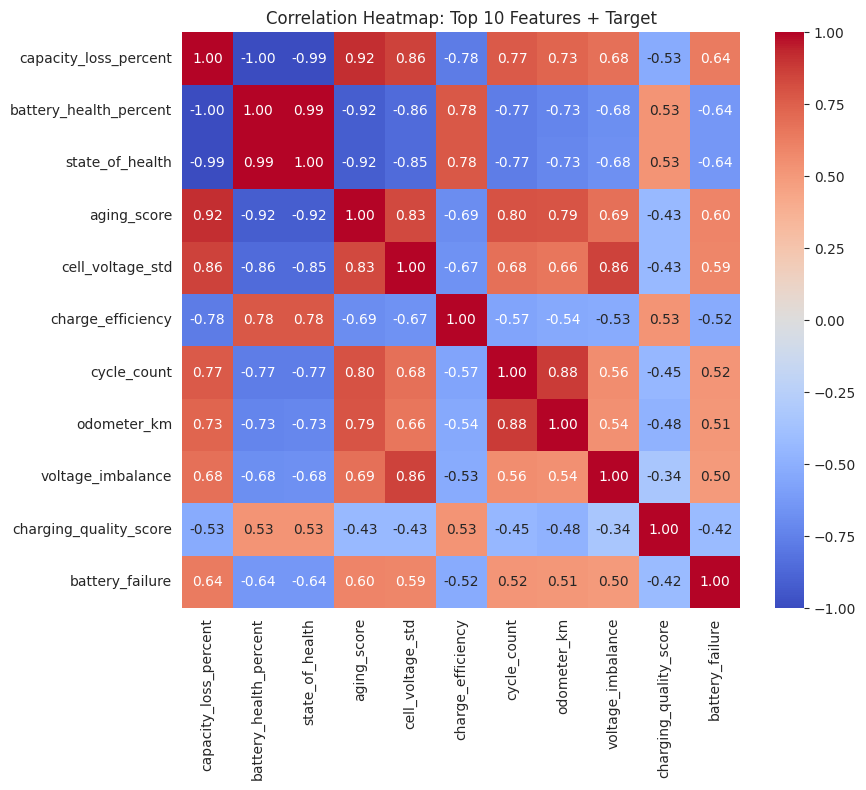

In [32]:
top_features = corr_with_target.abs().sort_values(ascending=False).index[1:11]

plt.figure(figsize=(9, 8))
sns.heatmap(df[top_features.tolist() + ["battery_failure"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap: Top 10 Features + Target")
plt.tight_layout()

# 11. Key Takeaways

- **Chemistry matters a lot.** LFP and LTO batteries show far lower failure rates
  than NMC, NCA, and LMO, consistent with their slower degradation and lower
  thermal-runaway risk.
- **Fleet usage is a strong risk factor.** Higher mileage, more fast charging,
  and more aggressive driving push fleet vehicles toward higher failure rates
  than privately owned ones.
- **Degradation signals dominate.** `capacity_loss_percent`, `battery_health_percent`,
  `aging_score`, and `cycle_count` are the strongest correlates of failure.
- **Diagnostics reinforce the physical story.** `thermal_runaway_risk`,
  `voltage_imbalance`, and `BMS_warning_count` all track closely with failure,
  as expected from how the dataset was constructed.
- **Charging and driving habits matter at the margins.** Fast charging, charging
  interruptions, and aggressive driving all nudge failure probability upward,
  while good maintenance and charging quality pull it back down.

This should give a solid base for feature engineering and model building,
next steps would typically include handling the class imbalance (e.g. class
weights or resampling), encoding the categorical columns, and trying tree-based
models (XGBoost, LightGBM, CatBoost) which tend to do well on this kind of
tabular data with nonlinear interactions.
